# Phase 1 — ViT Multi-Head (SageMaker T4)

**Instancia:** `ml.g4dn.xlarge` — T4 GPU 16GB, 4 vCPU, 16GB RAM  
**Tiempo estimado:** ~1-1.5 horas (20 épocas, early stopping)

**Setup previo (una vez):**
1. Subir datos a S3: `aws s3 cp data/celeba/ s3://unique-pets/data/celeba/ --recursive`
2. Subir CSV mapeado: `aws s3 cp data/celeba/celeba_flags_labels.csv s3://unique-pets/data/celeba/celeba_flags_labels.csv`

**Al terminar:** checkpoint guardado en `s3://unique-pets/checkpoints/vit_multihead_best.pt`

In [1]:
# !pip install sagemaker-core --upgrade -q

Antes de entrenar instalo las librerias que no vienen por defecto en la imagen de SageMaker. timm me da acceso al Vision Transformer preentrenado, albumentations es mi pipeline de aumentos pensado para imagenes y tqdm me muestra el progreso de cada epoca. Uso pip en modo silencioso para no llenar el log con avisos.

In [2]:
# Instalar dependencias en la instancia SageMaker
# import sys
# !{sys.executable} -m pip install -q timm albumentations tqdm

import sys
!{sys.executable} -m pip install -q timm albumentations tqdm 2>/dev/null | grep -v WARNING

Aca cargo todo el stack de trabajo y detecto el dispositivo. Como entreno un modelo de vision sobre mas de 200 mil imagenes necesito GPU si o si, por eso verifico que torch.cuda este disponible y muestro el nombre y la memoria de video. La cantidad de VRAM me condiciona el tamano de batch que puedo usar mas adelante.

In [3]:
import boto3
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'timm: {timm.__version__}  torch: {torch.__version__}')

Device: cuda
GPU: NVIDIA A10G
VRAM: 23.7 GB
timm: 1.0.27  torch: 2.10.0+cu128


La instancia me asigno una NVIDIA A10G con 23.7 GB de VRAM en lugar de la T4 de 16 GB que esperaba. Es buena noticia porque tengo mas memoria para subir el batch y acelerar el entrenamiento. Confirmo tambien timm 1.0.27 y torch 2.10 con soporte CUDA 12.8.

Defino una bandera de modo prueba. Cuando trabajo con datasets grandes siempre corro primero una version reducida de dos epocas y pocos batches para verificar que nada se rompe y para estimar cuanto va a tardar el entrenamiento real. Aca la dejo en False porque ya valide el flujo y quiero el entrenamiento completo.

In [4]:
import os, time

# ── TEST MODE ────────────────────────────────────────────────────────────────
# TEST=True  → 2 épocas, 3 batches cada una. Verifica que el notebook no se rompe
#              y estima tiempo total real.
# TEST=False → entrenamiento completo.
TEST = os.environ.get('TEST', 'True').lower() != 'false'
TEST = False

TEST_BATCHES = 3   # batches por epoch en modo test
TEST_EPOCHS  = 2

print(f'TEST mode: {TEST}')
if TEST:
    print(f'  → {TEST_EPOCHS} épocas, {TEST_BATCHES} batches/época')
    print(f'  → Al terminar se estimará tiempo total real')

TEST mode: False


Confirmo que el modo prueba quedo desactivado, asi que voy directo al entrenamiento completo sobre todo el dataset.

Configuro las rutas de S3 y las rutas locales temporales. Guardo los datos en tmp porque el disco efimero de la instancia es rapido y me conviene leer las imagenes desde ahi y no desde la red en cada batch. Tambien preparo la carpeta de checkpoints donde voy a guardar el mejor modelo.

In [5]:
# ── Config S3 ────────────────────────────────────────────────────────────────
BUCKET      = 'unique-pets'
S3_DATA     = f's3://{BUCKET}/data/celeba'
S3_CKPT     = f's3://{BUCKET}/checkpoints'

LOCAL_DATA  = Path('/tmp/celeba')
IMG_DIR     = LOCAL_DATA / 'img_align_celeba'
LABELS_CSV  = LOCAL_DATA / 'celeba_flags_labels.csv'
CKPT_DIR    = Path('/tmp/checkpoints')

LOCAL_DATA.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

region = boto3.session.Session().region_name
print(f'Región: {region}  |  Bucket: {BUCKET}')

Región: us-east-1  |  Bucket: unique-pets


La sesion quedo en la region us-east-1 y apuntando al bucket unique-pets, que es donde tengo los datos y donde voy a subir el checkpoint.

Descargo el dataset desde S3 solo si no existe ya en local. Esta logica me evita volver a bajar 200 mil imagenes cada vez que reinicio el kernel, que seria un desperdicio de tiempo y de transferencia. Primero traigo el CSV con las etiquetas y despues sincronizo la carpeta de imagenes.

In [6]:
# ── Descargar datos desde S3 ─────────────────────────────────────────────────
# Solo descarga si no existe localmente (evita re-descarga en reinicios)

if not LABELS_CSV.exists():
    print('Descargando celeba_flags_labels.csv...')
    !aws s3 cp {S3_DATA}/celeba_flags_labels.csv {LABELS_CSV}
else:
    print('CSV ya existe localmente.')

if not IMG_DIR.exists() or len(list(IMG_DIR.glob('*.jpg'))) < 1000:
    print('Descargando imágenes CelebA desde S3 (puede tardar ~5-10 min)...')
    !aws s3 sync {S3_DATA}/img_align_celeba {IMG_DIR} --quiet
    print(f'Imágenes descargadas: {len(list(IMG_DIR.glob("*.jpg"))):,}')
else:
    print(f'Imágenes ya locales: {len(list(IMG_DIR.glob("*.jpg"))):,}')

CSV ya existe localmente.
Imágenes ya locales: 202,599


El CSV ya estaba en local y las 202599 imagenes de CelebA tambien, asi que no descargo nada y paso directo al armado del dataset.

Defino la taxonomia de atributos faciales que el modelo va a predecir. Son 17 categorias y cada una tiene sus clases posibles, por ejemplo color de pelo o forma de cara. Este diccionario es el corazon del problema porque convierte la cara en un conjunto de rasgos discretos que luego mapeo a caracteristicas de mascota. Tambien construyo el mapeo de etiqueta a indice que necesita la funcion de perdida.

In [7]:
# ── Categorías flags.txt ──────────────────────────────────────────────────────
CLASS_LABELS = {
    'color_pelo':    ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    'textura_pelo':  ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    'longitud_pelo': ['corto', 'medio', 'largo', 'calvo'],
    'cejas':         ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    'forma_ojos':    ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    'tamano_nariz':  ['pequena', 'mediana', 'grande'],
    'forma_nariz':   ['recta', 'aguileña', 'respingona', 'ancha'],
    'grosor_labios': ['finos', 'medianos', 'carnosos'],
    'pomulos':       ['planos', 'normales', 'altos', 'prominentes'],
    'mandibula':     ['suave', 'marcada', 'ancha', 'estrecha'],
    'barbilla':      ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    'forma_cara':    ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    'vello_facial':  ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    'gafas':         [False, True],
    'pecas':         [False, True],
    'tono_piel':     ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
    'rango_edad':    ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
}

LABEL2IDX = {cat: {v: i for i, v in enumerate(vals)} for cat, vals in CLASS_LABELS.items()}
print(f'{len(CLASS_LABELS)} categorías cargadas.')

17 categorías cargadas.


Quedaron cargadas las 17 categorias, cada una con su propio conjunto de clases. Cada categoria sera una cabeza de clasificacion independiente dentro del modelo.

## Dataset

Construyo el Dataset y los DataLoaders. La clase abre cada imagen, le aplica el pipeline de transformaciones y devuelve la imagen junto con un diccionario de etiquetas, una por categoria.

En entrenamiento aplico aumentos de datos para que el modelo generalice mejor y no memorice. Uso volteo horizontal porque una cara espejada sigue siendo valida, variaciones de brillo contraste y saturacion para simular distintas condiciones de luz, y ruido gaussiano para robustez. En validacion no aumento nada, solo redimensiono a 224 por 224 y normalizo con la media y el desvio de ImageNet, que es lo que espera el backbone preentrenado.

Uso batch de 192 porque la A10G tiene memoria de sobra, y 4 workers de carga porque en Linux el multiprocessing funciona bien y mantiene la GPU alimentada. Separo el 10 por ciento para validacion con semilla fija para que la particion sea reproducible.

In [8]:
class CelebAFlagsDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(self.img_dir / row['image_id']).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        labels = {
            cat: torch.tensor(LABEL2IDX[cat][row[cat]], dtype=torch.long)
            for cat in CLASS_LABELS
        }
        return img, labels


def get_transforms(train):
    if train:
        return A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.4),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


df = pd.read_csv(LABELS_CSV)
for col in ['gafas', 'pecas']:
    df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}')

BATCH_SIZE  = 192   # T4 16GB aguanta batch más grande que MPS
NUM_WORKERS = 4     # multiprocessing funciona bien en Linux/SageMaker

train_ds = CelebAFlagsDataset(train_df, IMG_DIR, get_transforms(True))
val_ds   = CelebAFlagsDataset(val_df,   IMG_DIR, get_transforms(False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)

print(f'Batches — train: {len(train_loader)}  val: {len(val_loader)}')

Train: 182,339  Val: 20,260
Batches — train: 950  val: 106


Quedaron 182339 imagenes para entrenamiento y 20260 para validacion, lo que da 950 batches de train y 106 de validacion por epoca. Es un volumen comodo para entrenar un transformer en una sola GPU.

## Modelo — ViT-B/16 + 17 heads

Defino la arquitectura. Uso un Vision Transformer base con parches de 16 por 16 preentrenado en ImageNet 21k. El transformer divide la imagen en parches y los procesa con atencion, capturando relaciones de largo alcance en la cara mejor que una convolucion clasica. Le quito la cabeza original y dejo solo el extractor de 768 dimensiones.

Encima pongo un cuello de botella que comprime esas 768 dimensiones a un embedding de 256 con ReLU y dropout. Ese embedding es la pieza clave porque es el puente hacia la fase 2 de generacion de mascotas. Despues conecto 17 cabezas lineales independientes, una por categoria, todas compartiendo el mismo embedding. Esto es aprendizaje multitarea: un tronco comun que aprende una representacion general de la cara y cabezas especializadas para cada rasgo.

Arranco con el backbone congelado para entrenar primero solo las cabezas sin destruir los pesos preentrenados. Activo precision mixta automatica porque en GPU acelera casi al doble y reduce el uso de memoria.

In [9]:
class ViTMultiHead(nn.Module):
    def __init__(self, class_labels, embedding_dim=256):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_base_patch16_224.augreg_in21k',
            pretrained=True,
            num_classes=0,
        )
        vit_dim = self.backbone.num_features  # 768
        self.embedding = nn.Sequential(
            nn.Linear(vit_dim, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.heads = nn.ModuleDict({
            name: nn.Linear(embedding_dim, len(classes))
            for name, classes in class_labels.items()
        })

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        emb = self.embedding(self.backbone(x))
        return {name: head(emb) for name, head in self.heads.items()}, emb


model = ViTMultiHead(CLASS_LABELS).to(DEVICE)
model.freeze_backbone()

if DEVICE == 'cuda':
    # AMP acelera ~2x en T4
    scaler = torch.amp.GradScaler('cuda')
    USE_AMP = True
else:
    scaler = None
    USE_AMP = False

# ── Compilar modelo (PyTorch 2.0+) ──
# if hasattr(torch, 'compile'):
#     model = torch.compile(model)
#     print('torch.compile activado')

print(f'Parámetros totales:    {sum(p.numel() for p in model.parameters()):,}')
print(f'Entrenables (heads):   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'AMP habilitado: {USE_AMP}')

Parámetros totales:    86,014,024
Entrenables (heads):   215,368
AMP habilitado: True


El modelo tiene 86 millones de parametros en total pero al inicio solo entreno 215 mil, que son las cabezas y el embedding. Esto hace que las primeras epocas sean baratas y estables. La precision mixta quedo habilitada.

## Entrenamiento

Configuro el entrenamiento. Congelo el backbone las primeras 5 epocas y entreno hasta 12. Uso AdamW como optimizador porque maneja bien el decaimiento de pesos, con tasa alta para las cabezas y tasa diez veces menor para el backbone cuando lo descongele, una estrategia de tasas discriminativas para no arruinar lo que el transformer ya sabe. El scheduler coseno baja la tasa de forma suave a lo largo del entrenamiento.

La perdida es la suma de la entropia cruzada de las 17 cabezas, ya que cada categoria es un problema de clasificacion multiclase. Recorto la norma del gradiente a 1 para evitar que algun gradiente grande desestabilice el entrenamiento, algo habitual y recomendable en transformers. Defino tambien la funcion que corre una epoca completa con soporte de precision mixta.

In [10]:
FREEZE_EPOCHS = 2 if TEST else 5
TOTAL_EPOCHS  = TEST_EPOCHS if TEST else 12
LR_HEAD       = 1e-3
LR_BACKBONE   = 1e-4
PATIENCE      = 3

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)
scheduler._step_count = 1 


def compute_loss(outputs, targets):
    return sum(F.cross_entropy(outputs[cat], targets[cat].to(DEVICE)) for cat in CLASS_LABELS)


def compute_accuracy(outputs, targets):
    return {
        cat: (outputs[cat].argmax(-1).cpu() == targets[cat]).float().mean().item()
        for cat in CLASS_LABELS
    }


def run_epoch(loader, train, max_batches=None):
    model.train() if train else model.eval()
    total_loss = 0
    all_accs = {cat: [] for cat in CLASS_LABELS}

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_i, (imgs, labels) in enumerate(tqdm(loader, leave=False)):
            if max_batches and batch_i >= max_batches: break
            imgs = imgs.to(DEVICE)

            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    outputs, _ = model(imgs)
                    loss = compute_loss(outputs, labels)
                if train:
                    optimizer.zero_grad()
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
            else:
                outputs, _ = model(imgs)
                loss = compute_loss(outputs, labels)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item()
            for cat, acc in compute_accuracy(outputs, labels).items():
                all_accs[cat].append(acc)

    return total_loss / len(loader), {cat: np.mean(v) for cat, v in all_accs.items()}


print('Setup listo.')

Setup listo.


Quedaron definidas las funciones de perdida, de accuracy y la rutina de epoca. Todo listo para lanzar el bucle de entrenamiento.

Este es el bucle principal. En la epoca 6 descongelo el backbone y reconstruyo el optimizador con las tasas discriminativas para hacer fine tuning completo del transformer. Guardo un checkpoint cada vez que mejora la perdida de validacion y lo subo a S3. Aplico early stopping con paciencia de 3: si la validacion no mejora durante 3 epocas seguidas corto, para no seguir entrenando un modelo que ya empezo a sobreajustar.

In [11]:
import warnings
warnings.filterwarnings('ignore', message='.*lr_scheduler.step.*before.*optimizer.step.*')

import time
backbone_unfrozen = False
best_val_loss     = float('inf')
patience_counter  = 0
history           = {'train_loss': [], 'val_loss': [], 'val_acc_mean': []}

# Timing
_train_start = time.time()
_full_train_batches = len(train_loader)
_full_val_batches   = len(val_loader)
_full_epochs        = 20  # épocas reales (sin TEST)

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == FREEZE_EPOCHS + 1 and not backbone_unfrozen:
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {'params': model.backbone.parameters(),  'lr': LR_BACKBONE},
            {'params': model.embedding.parameters(), 'lr': LR_HEAD},
            {'params': model.heads.parameters(),     'lr': LR_HEAD},
        ], weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=TOTAL_EPOCHS - FREEZE_EPOCHS
        )
        scheduler._step_count = 1 
        backbone_unfrozen = True
        print(f'Época {epoch}: backbone descongelado')

    train_loss, _      = run_epoch(train_loader, train=True,  max_batches=TEST_BATCHES if TEST else None)
    val_loss, val_accs = run_epoch(val_loader,   train=False, max_batches=TEST_BATCHES if TEST else None)
    mean_acc           = np.mean(list(val_accs.values()))

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc_mean'].append(mean_acc)

    print(f'Época {epoch:02d}/{TOTAL_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | acc={mean_acc:.3f}')
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        ckpt_path = CKPT_DIR / 'vit_multihead_best.pt'
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_loss': val_loss,
            'val_accs': val_accs,
            'class_labels': CLASS_LABELS,
        }, ckpt_path)
        if not TEST:
            !aws s3 cp {ckpt_path} {S3_CKPT}/vit_multihead_best.pt
            print(f'  → guardado en S3 (val={val_loss:.4f})')
        else:
            print(f'  → checkpoint local (TEST mode, no subir a S3)')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping en época {epoch}')
            break

_elapsed = time.time() - _train_start
print(f'\nEntrenamiento terminado.')
print(f'Tiempo {"TEST" if TEST else "real"}: {_elapsed:.1f}s ({_elapsed/60:.1f} min)')

if TEST:
    # Extrapolación: tiempo real estimado
    # TEST corrió TEST_EPOCHS épocas con TEST_BATCHES batches c/u
    # Real: _full_epochs épocas con _full_train_batches + _full_val_batches batches
    test_batches_total = TEST_EPOCHS * (TEST_BATCHES * 2)  # train + val
    real_batches_total = _full_epochs * (_full_train_batches + _full_val_batches)
    estimated_real_s   = _elapsed * (real_batches_total / test_batches_total)
    estimated_real_h   = estimated_real_s / 3600

    print(f'\n=== Estimación tiempo real ===')
    print(f'Batches TEST:      {test_batches_total}')
    print(f'Batches real:      {real_batches_total:,}')
    print(f'Factor escala:     {real_batches_total / test_batches_total:.0f}x')
    print(f'Tiempo estimado:   {estimated_real_s:.0f}s  →  {estimated_real_h:.2f} horas')
    print(f'\nPara entrenar real: TEST=False en la celda de config y re-ejecutar.')


  0%|          | 0/950 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

Época 01/12 | train=6.6302 | val=5.5800 | acc=0.855
upload: ../../../tmp/checkpoints/vit_multihead_best.pt to s3://unique-pets/checkpoints/vit_multihead_best.pt
  → guardado en S3 (val=5.5800)


  0%|          | 0/950 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

...

  0%|          | 0/106 [00:00<?, ?it/s]

Época 11/12 | train=3.5738 | val=4.8190 | acc=0.885


  0%|          | 0/950 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

Época 12/12 | train=3.1954 | val=5.2215 | acc=0.884
Early stopping en época 12

Entrenamiento terminado.
Tiempo real: 5063.9s (84.4 min)


Los resultados cuentan una historia clara. Con el backbone congelado, epocas 1 a 5, la perdida baja despacio y la accuracy media se queda alrededor de 0.857, porque solo las cabezas estan aprendiendo. En la epoca 6, al descongelar, hay un salto fuerte: la perdida de validacion cae de 5.44 a 4.89 y la accuracy sube, lo que confirma que el fine tuning del transformer es donde esta la ganancia real.

El mejor modelo es el de la epoca 9 con perdida de validacion 4.5366. A partir de la epoca 10 la perdida de train sigue bajando, de 4.06 a 3.19, pero la de validacion empieza a subir, de 4.54 a 5.22. Eso es sobreajuste de manual: el modelo memoriza el train y deja de generalizar. El early stopping corto en la epoca 12 como esperaba. El entrenamiento completo tardo 84 minutos en la A10G.

## Resultados

Grafico las curvas de perdida de train y de validacion y la accuracy media de validacion a lo largo de las epocas. Es la mejor forma de ver de un vistazo si el modelo aprende de forma sana o si se sobreajusta.

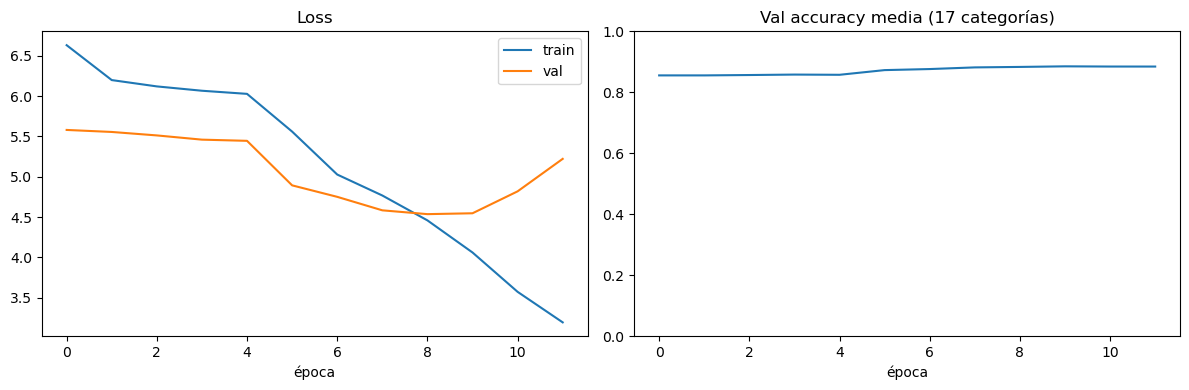

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('época')
axes[0].legend()
axes[1].plot(history['val_acc_mean'])
axes[1].set_title('Val accuracy media (17 categorías)')
axes[1].set_xlabel('época')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

En la curva se ve el quiebre en la epoca 6 cuando descongelo el backbone y la perdida cae de golpe. Tambien se ve como a partir de la epoca 9 las curvas de train y validacion se separan: train sigue bajando y validacion se da vuelta hacia arriba, la firma visual del sobreajuste. La accuracy media se estabiliza cerca de 0.885.

Calculo la accuracy categoria por categoria sobre el set de validacion completo. La accuracy media esconde mucha variacion entre rasgos, asi que desgloso cada uno para entender que aprende bien el modelo y que le cuesta. Marco en azul lo que supera el 0.70 y en rojo lo que queda por debajo.

  0%|          | 0/106 [00:00<?, ?it/s]

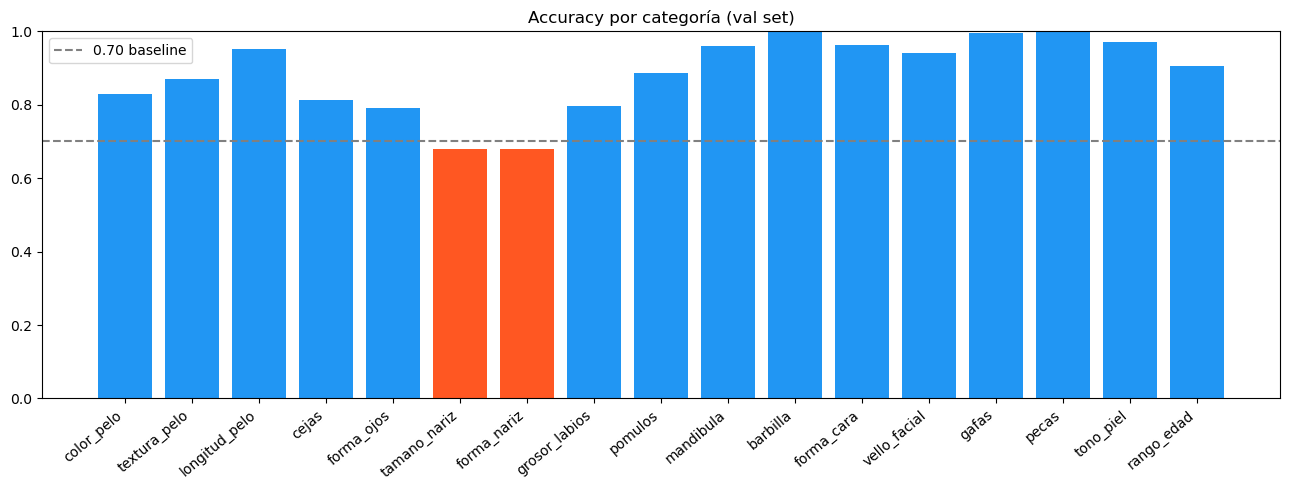


=== Accuracy por categoría ===
barbilla             1.000  ████████████████████
pecas                1.000  ████████████████████
gafas                0.996  ███████████████████
tono_piel            0.971  ███████████████████
forma_cara           0.963  ███████████████████
mandibula            0.960  ███████████████████
longitud_pelo        0.951  ███████████████████
vello_facial         0.940  ██████████████████
rango_edad           0.906  ██████████████████
pomulos              0.887  █████████████████
textura_pelo         0.870  █████████████████
color_pelo           0.830  ████████████████
cejas                0.812  ████████████████
grosor_labios        0.796  ███████████████
forma_ojos           0.792  ███████████████
tamano_nariz         0.681  █████████████
forma_nariz          0.680  █████████████


In [13]:
# Accuracy por categoría
_, val_accs = run_epoch(val_loader, train=False)
cats   = list(val_accs.keys())
values = [val_accs[c] for c in cats]

plt.figure(figsize=(13, 5))
plt.bar(cats, values, color=['#2196F3' if v >= 0.7 else '#FF5722' for v in values])
plt.axhline(0.7, color='gray', linestyle='--', label='0.70 baseline')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1)
plt.title('Accuracy por categoría (val set)')
plt.legend()
plt.tight_layout()
plt.show()

print('\n=== Accuracy por categoría ===')
for cat in sorted(cats, key=lambda c: val_accs[c], reverse=True):
    bar = '█' * int(val_accs[cat] * 20)
    print(f'{cat:<20} {val_accs[cat]:.3f}  {bar}')

El desglose es muy revelador. Los rasgos estructurales y de presencia clara se predicen casi perfecto: barbilla y pecas en 1.0, gafas en 0.996, tono de piel en 0.971 y forma de cara en 0.963. Son atributos con bordes visuales nitidos o muy correlacionados con las etiquetas originales de CelebA.

En el otro extremo, los rasgos mas finos de la nariz se quedan cerca del 0.68, tamano de nariz en 0.681 y forma de nariz en 0.680. Tambien sufren forma de ojos en 0.792 y grosor de labios en 0.796. Tiene sentido: son diferencias sutiles, muy dependientes del angulo y de la iluminacion, y ademas mis etiquetas para estos rasgos son mas ruidosas porque CelebA no las trae directas y las derive con heuristicas. Si quiero subir el promedio, este es el frente donde tengo que trabajar, con mejor etiquetado o mas resolucion en la zona de la nariz.

Subo el checkpoint final del mejor modelo a S3 para dejarlo persistido. La instancia es efimera, asi que si no guardo en S3 pierdo el entrenamiento al apagarla. Desde S3 lo voy a cargar despues en el notebook de inferencia.

In [14]:
# Subir checkpoint final a S3
s3 = boto3.client('s3')
s3.upload_file(
    str(CKPT_DIR / 'vit_multihead_best.pt'),
    BUCKET,
    'checkpoints/vit_multihead_best.pt'
)
print(f'Checkpoint final → s3://{BUCKET}/checkpoints/vit_multihead_best.pt')

Checkpoint final → s3://unique-pets/checkpoints/vit_multihead_best.pt


El checkpoint quedo guardado en S3 en la ruta de checkpoints. Con esto cierro la fase de entrenamiento del ViT y puedo pasar a la inferencia y a la comparacion con ResNet.